# MLB Schedule Optimization — Exploratory Data Analysis (EDA)

This notebook performs EDA on the 2025 MLB Retrosheet data to populate and validate
the parameters of our Mixed-Integer Linear Programming (MILP) model.

**Objective:** Minimize total league-wide travel distance subject to real-world
scheduling constraints.

$$\min \sum_{a \in T} \sum_{b \in C} \sum_{c \in C} \sum_{d \in D} Dist_{b,c} \cdot A_{a,b,c,d}$$

In [1]:
# ============================================================
# 0.  IMPORTS & CONFIGURATION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='whitegrid', palette='viridis', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 8)

print('All imports successful ✓')

All imports successful ✓


In [2]:
# ============================================================
# 0a.  LOAD RAW DATA
# ============================================================
# --- Retrosheet Game Logs (headerless CSV — standard 161-column layout) ---
# Key columns:  0=Date, 3=VisitingTeam, 6=HomeTeam, 16=ParkID
GL_COLS_USED = [0, 3, 6, 16]
GL_COL_NAMES = ['Date', 'VisitingTeam', 'HomeTeam', 'ParkID']

gl = pd.read_csv(
    r'alldata_2025/gamelogs/gl2025.txt',
    header=None,
    usecols=GL_COLS_USED,
    names=GL_COL_NAMES,
    dtype=str
)

# Parse date
gl['Date'] = pd.to_datetime(gl['Date'], format='%Y%m%d')

# --- Team file ---
teams_df = pd.read_csv(
    r'alldata_2025/teams/TEAM2025',
    header=None,
    names=['TeamID', 'League', 'City', 'Nickname']
)

# Drop All-Star rows (ALS, NLS) — not real teams
teams_df = teams_df[~teams_df['TeamID'].isin(['ALS', 'NLS'])].reset_index(drop=True)

print(f'Game log rows loaded : {len(gl):,}')
print(f'Teams loaded         : {len(teams_df)}')
gl.head(10)

Game log rows loaded : 2,430
Teams loaded         : 30


,Date,VisitingTeam,HomeTeam,ParkID
0,2025-03-18,LAN,CHN,TOK01
1,2025-03-19,LAN,CHN,TOK01
2,2025-03-27,CHN,ARI,PHO01
3,2025-03-27,SFN,CIN,CIN09
4,2025-03-27,DET,LAN,LOS03
5,2025-03-27,PIT,MIA,MIA02
6,2025-03-27,ATL,SDN,SAN02
7,2025-03-27,MIN,SLN,STL10
8,2025-03-27,PHI,WAS,WAS11
9,2025-03-27,ANA,CHA,CHI12


---
## Task 1 — Define Sets & Home Stadium Mapping ($T$, $C$, $H_a$)

We extract:
- **$T$:** The set of all 30 MLB teams (Retrosheet 3-letter codes).
- **$C$:** The set of all active stadiums (Park IDs) used in the season.
- **$H_a$:** A mapping from each team $a$ to its *primary* home stadium.

### MILP Justification
$H_a$ anchors every team to a "home base" in the routing model.  When a team is
at home, we know exactly which stadium vertex they occupy in the travel graph.
This mapping is required by the constraint that fixes team $a$'s location to
$H_a$ on home-game days.

In [3]:
# ============================================================
# TASK 1:  SETS  T, C  &  HOME-STADIUM MAPPING  H_a
# ============================================================

# --- Set T: All 30 teams ---
T = sorted(teams_df['TeamID'].unique())
print(f'|T| = {len(T)} teams')
print(T)
print()

# --- Set C: All active stadiums ---
# These are all unique ParkIDs that appear in the game log.
C = sorted(gl['ParkID'].unique())
print(f'|C| = {len(C)} stadiums')
print(C)
print()

# --- H_a:  Home stadium mapping ---
# For each team, find the stadium where they host the most games.
# This handles neutral-site games (e.g., Tokyo TOK01) correctly.
home_games = gl.groupby(['HomeTeam', 'ParkID']).size().reset_index(name='Games')
home_games = home_games.sort_values('Games', ascending=False)

# Keep the top park per team
H_a = (
    home_games
    .sort_values('Games', ascending=False)
    .drop_duplicates(subset='HomeTeam', keep='first')
    .set_index('HomeTeam')['ParkID']
    .to_dict()
)

# Build a presentable DataFrame
ha_df = pd.DataFrame([
    {'Team': t,
     'City': teams_df.loc[teams_df['TeamID']==t, 'City'].values[0],
     'Nickname': teams_df.loc[teams_df['TeamID']==t, 'Nickname'].values[0],
     'HomePark (H_a)': H_a.get(t, 'N/A')}
    for t in T
])

print('Home Stadium Mapping  H_a :')
ha_df.style.set_caption('H_a — Team → Home Stadium')

|T| = 30 teams
['ANA', 'ARI', 'ATH', 'ATL', 'BAL', 'BOS', 'CHA', 'CHN', 'CIN', 'CLE', 'COL', 'DET', 'HOU', 'KCA', 'LAN', 'MIA', 'MIL', 'MIN', 'NYA', 'NYN', 'PHI', 'PIT', 'SDN', 'SEA', 'SFN', 'SLN', 'TBA', 'TEX', 'TOR', 'WAS']

|C| = 33 stadiums
['ANA01', 'ARL03', 'ATL03', 'BAL12', 'BOS07', 'BST01', 'CHI11', 'CHI12', 'CIN09', 'CLE08', 'DEN02', 'DET05', 'HOU03', 'KAN06', 'LOS03', 'MIA02', 'MIL06', 'MIN04', 'NYC20', 'NYC21', 'PHI13', 'PHO01', 'PIT08', 'SAC01', 'SAN02', 'SEA03', 'SFO03', 'STL10', 'TAM02', 'TOK01', 'TOR02', 'WAS11', 'WIL02']

Home Stadium Mapping  H_a :


,Team,City,Nickname,HomePark (H_a)
0,ANA,Anaheim,Angels,ANA01
1,ARI,Arizona,Diamondbacks,PHO01
2,ATH,Sacramento,Athletics,SAC01
3,ATL,Atlanta,Braves,ATL03
4,BAL,Baltimore,Orioles,BAL12
5,BOS,Boston,Red Sox,BOS07
6,CHA,Chicago,White Sox,CHI12
7,CHN,Chicago,Cubs,CHI11
8,CIN,Cincinnati,Reds,CIN09
9,CLE,Cleveland,Guardians,CLE08


In [5]:
# Pretty-print the mapping dictionary (directly usable in Pyomo)
print('H_a dictionary for Pyomo(or other solver):')
for team, park in sorted(H_a.items()):
    city = teams_df.loc[teams_df['TeamID']==team, 'City'].values[0]
    print(f"  '{team}': '{park}',   # {city}")

H_a dictionary for Pyomo(or other solver):
  'ANA': 'ANA01',   # Anaheim
  'ARI': 'PHO01',   # Arizona
  'ATH': 'SAC01',   # Sacramento
  'ATL': 'ATL03',   # Atlanta
  'BAL': 'BAL12',   # Baltimore
  'BOS': 'BOS07',   # Boston
  'CHA': 'CHI12',   # Chicago
  'CHN': 'CHI11',   # Chicago
  'CIN': 'CIN09',   # Cincinnati
  'CLE': 'CLE08',   # Cleveland
  'COL': 'DEN02',   # Colorado
  'DET': 'DET05',   # Detroit
  'HOU': 'HOU03',   # Houston
  'KCA': 'KAN06',   # Kansas City
  'LAN': 'LOS03',   # Los Angeles
  'MIA': 'MIA02',   # Miami
  'MIL': 'MIL06',   # Milwaukee
  'MIN': 'MIN04',   # Minnesota
  'NYA': 'NYC21',   # New York
  'NYN': 'NYC20',   # New York
  'PHI': 'PHI13',   # Philadelphia
  'PIT': 'PIT08',   # Pittsburgh
  'SDN': 'SAN02',   # San Diego
  'SEA': 'SEA03',   # Seattle
  'SFN': 'SFO03',   # San Francisco
  'SLN': 'STL10',   # St. Louis
  'TBA': 'TAM02',   # Tampa Bay
  'TEX': 'ARL03',   # Texas
  'TOR': 'TOR02',   # Toronto
  'WAS': 'WAS11',   # Washington


---
## Task 2 — Build the Matchup Matrix ($M_{a,j}$)

**$M_{a,j}$** = number of away games team $a$ must play at team $j$'s home.

This matrix is passed directly to the MILP constraint:
$$\sum_{d \in D} G_{a,j,d} = M_{a,j} \quad \forall \; a, j \in T$$

which ensures that the optimized schedule honors the exact same matchup counts
as the historical schedule.

In [6]:
# ============================================================
# TASK 2:  MATCHUP MATRIX  M_{a,j}
# ============================================================

# Count games: rows = VisitingTeam (away), columns = HomeTeam
matchup_counts = (
    gl.groupby(['VisitingTeam', 'HomeTeam'])
    .size()
    .reset_index(name='Games')
)

# Pivot to 30x30 matrix
M_aj = matchup_counts.pivot(
    index='VisitingTeam',
    columns='HomeTeam',
    values='Games'
).fillna(0).astype(int)

# Ensure both axes include all 30 teams in sorted order
M_aj = M_aj.reindex(index=T, columns=T, fill_value=0)

print(f'Matchup matrix shape  : {M_aj.shape}')
print(f'Total games in matrix : {M_aj.values.sum():,}')
print(f'Total unique games in game log : {len(gl):,}')
print()
M_aj.head(10)

Matchup matrix shape  : (30, 30)
Total games in matrix : 2,430
Total unique games in game log : 2,430



HomeTeam,ANA,ARI,ATH,ATL,BAL,BOS,CHA,CHN,CIN,CLE,...,PHI,PIT,SDN,SEA,SFN,SLN,TBA,TEX,TOR,WAS
VisitingTeam,,,,,,,,,,,,,,,,,,,,,
ANA,0,0,7,3,3,3,3,0,0,3,...,3,0,3,6,0,3,3,6,3,0
ARI,3,0,3,3,0,0,3,3,3,0,...,3,3,7,0,6,3,0,3,3,3
ATH,6,0,0,0,3,3,3,0,0,3,...,0,3,0,7,3,3,3,7,4,3
ATL,0,3,3,0,0,3,0,3,3,3,...,7,3,4,0,3,3,3,3,3,6
BAL,3,3,3,3,0,6,3,3,0,4,...,3,0,3,3,3,0,7,3,7,3
BOS,3,3,3,3,7,0,3,3,0,3,...,3,0,3,3,3,0,6,4,6,3
CHA,3,0,3,3,3,4,0,3,3,6,...,0,3,0,3,0,0,3,3,3,3
CHN,3,4,3,3,0,0,3,0,7,0,...,3,6,3,0,3,7,0,0,3,3
CIN,3,3,3,4,3,3,0,6,0,3,...,3,7,3,0,3,6,0,0,0,3


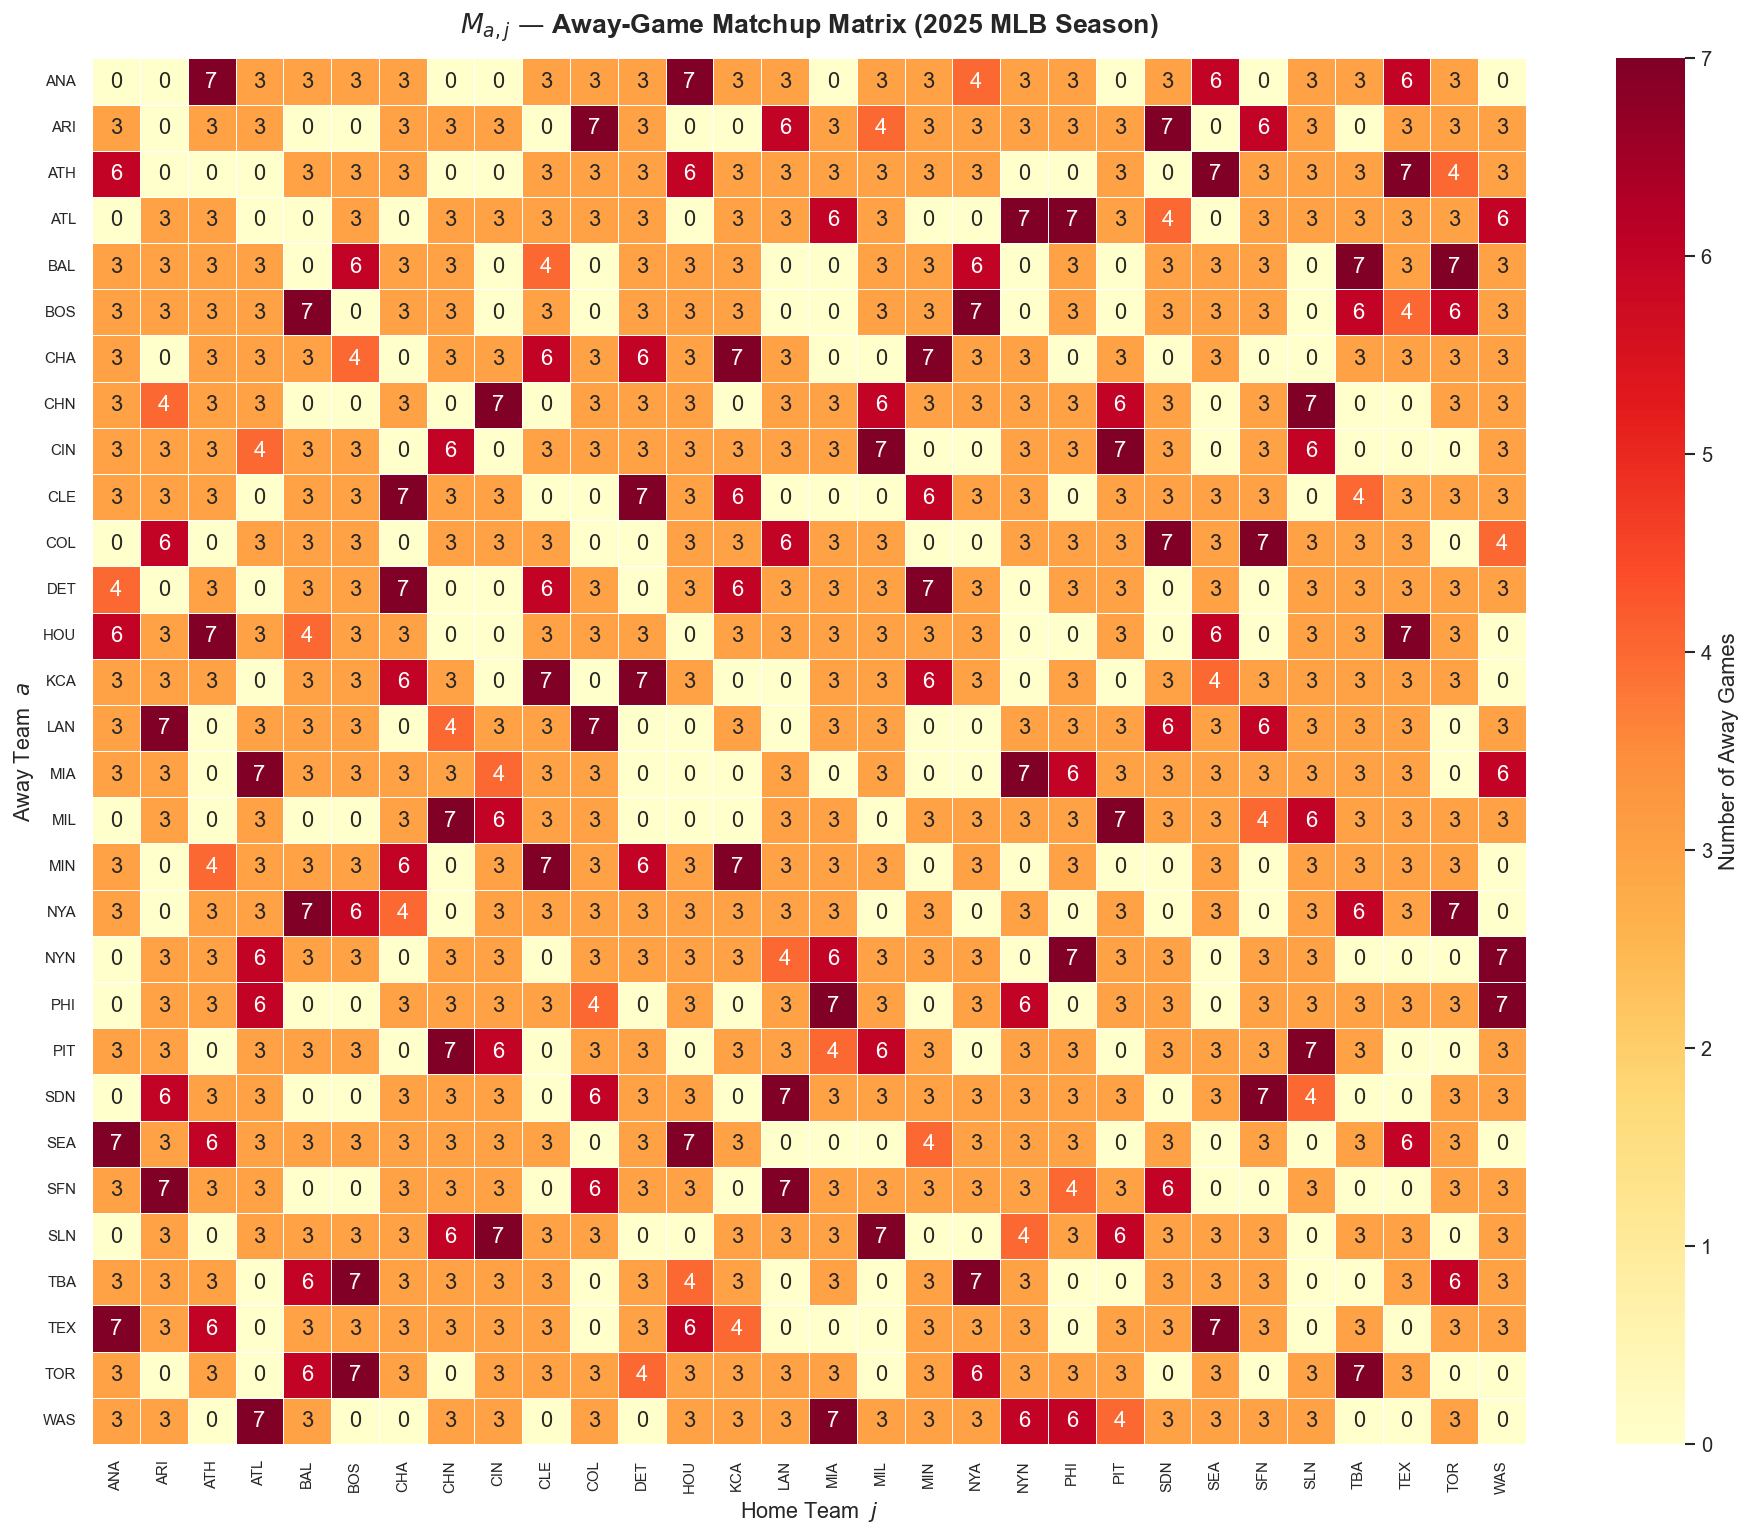


--- Key observations ---
• Diagonal is 0 (a team never visits itself).
• Division opponents show higher counts (~6-7 games) vs. inter-league (~3-4).
• This matrix is fed directly into the constraint: Σ_d G(a,j,d) = M(a,j).


In [ ]:
# ---- Heatmap Visualization ----
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    M_aj,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Number of Away Games'},
    ax=ax
)
ax.set_title('$M_{a,j}$ — Away-Game Matchup Matrix (2025 MLB Season)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Home Team  $j$', fontsize=13)
ax.set_ylabel('Away Team  $a$', fontsize=13)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.show()

print('\n Key observations')
print('• Diagonal is 0 (a team never visits itself).')
print('• Division opponents show higher counts (~6-7 games) vs. inter-league (~3-4).')
print('• This matrix is fed directly into the constraint: Σ_d G(a,j,d) = M(a,j).')

In [ ]:
# Double check (teams should play 81 home + 81 away games (162 games total))
games_per_team_away = M_aj.sum(axis=1)  # total away games per team
games_per_team_home = M_aj.sum(axis=0)  # total home games per team
total_per_team = games_per_team_away + games_per_team_home

check_df = pd.DataFrame({
    'Away Games': games_per_team_away,
    'Home Games': games_per_team_home,
    'Total': total_per_team
}).sort_index()

print('Games per team (should be ~81 home + ~81 away = ~162 total):')
check_df

Games per team (should be ~81 home + ~81 away = ~162 total):


,Away Games,Home Games,Total
ANA,81,81,162
ARI,81,81,162
ATH,81,81,162
ATL,81,81,162
BAL,81,81,162
BOS,81,81,162
CHA,81,81,162
CHN,81,81,162
CIN,81,81,162
CLE,81,81,162


---
## Task 3 — Calculate the Distance Matrix ($Dist_{b,c}$)

We need pairwise geodesic distances (in miles) between all stadiums.
Since we don't have a separate stadium coordinates file, we'll define
coordinates from known MLB stadium locations and use the **Haversine formula**.

In [9]:
# ============================================================
# TASK 3:  DISTANCE MATRIX  Dist_{b,c}
# ============================================================

# --- Stadium Coordinates (Lat, Lon) ---
# Using known 2025 MLB stadium locations.  Park IDs from Retrosheet.
# Note: ATH moved to Sacramento (SAC01) in 2025; Tokyo (TOK01) is a neutral site.

stadium_coords = {
    # American League
    'ANA01': ('Angel Stadium',          'ANA', 33.8003, -117.8827),   # Anaheim
    'ARL03': ('Globe Life Field',       'TEX', 32.7473, -97.0845),    # Arlington
    'BAL12': ('Camden Yards',           'BAL', 39.2838, -76.6217),    # Baltimore
    'BOS07': ('Fenway Park',            'BOS', 42.3467, -71.0972),    # Boston
    'CHI12': ('Guaranteed Rate Field',  'CHA', 41.8299, -87.6338),    # Chicago (South)
    'CLE08': ('Progressive Field',      'CLE', 41.4962, -81.6852),    # Cleveland
    'DET05': ('Comerica Park',          'DET', 42.3390, -83.0485),    # Detroit
    'HOU03': ('Minute Maid Park',       'HOU', 29.7573, -95.3555),    # Houston
    'KAN06': ('Kauffman Stadium',       'KCA', 39.0517, -94.4803),    # Kansas City
    'MIN04': ('Target Field',           'MIN', 44.9817, -93.2776),    # Minneapolis
    'NYC21': ('Yankee Stadium',         'NYA', 40.8296, -73.9262),    # Bronx, NY
    'SAC01': ('Sutter Health Park',     'ATH', 38.5805, -121.5087),   # Sacramento (A's)
    'SEA03': ('T-Mobile Park',          'SEA', 47.5914, -122.3325),   # Seattle
    'TAM02': ('Tropicana Field',        'TBA', 27.7682, -82.6534),    # St. Petersburg
    'TOR02': ('Rogers Centre',          'TOR', 43.6414, -79.3894),    # Toronto
    # National League
    'PHO01': ('Chase Field',            'ARI', 33.4455, -112.0667),   # Phoenix
    'ATL03': ('Truist Park',            'ATL', 33.8907, -84.4677),    # Atlanta
    'CHI11': ('Wrigley Field',          'CHN', 41.9484, -87.6553),    # Chicago (North)
    'CIN09': ('Great American Ball Park','CIN', 39.0975, -84.5069),   # Cincinnati
    'DEN02': ('Coors Field',            'COL', 39.7559, -104.9942),   # Denver
    'LOS03': ('Dodger Stadium',         'LAN', 34.0739, -118.2400),   # Los Angeles
    'MIA02': ('LoanDepot Park',         'MIA', 25.7781, -80.2196),    # Miami
    'MIL06': ('American Family Field',  'MIL', 43.0280, -87.9712),    # Milwaukee
    'NYC20': ('Citi Field',             'NYN', 40.7571, -73.8458),    # Queens, NY
    'PHI13': ('Citizens Bank Park',     'PHI', 39.9061, -75.1665),    # Philadelphia
    'PIT08': ('PNC Park',               'PIT', 40.4469, -80.0057),    # Pittsburgh
    'SAN02': ('Petco Park',             'SDN', 32.7076, -117.1570),   # San Diego
    'SFO03': ('Oracle Park',            'SFN', 37.7786, -122.3893),   # San Francisco
    'STL10': ('Busch Stadium',          'SLN', 38.6226, -90.1928),    # St. Louis
    'WAS11': ('Nationals Park',         'WAS', 38.8730, -77.0074),    # Washington DC
    # Neutral site (other side of the world)
    'TOK01': ('Tokyo Dome',             'N/A', 35.7056,  139.7519),   # Tokyo
}

# Build a DataFrame
coords_df = pd.DataFrame([
    {'ParkID': pid, 'StadiumName': v[0], 'PrimaryTeam': v[1], 'Lat': v[2], 'Lon': v[3]}
    for pid, v in stadium_coords.items()
])

print(f'Stadium coordinates loaded: {len(coords_df)}')
coords_df.sort_values('ParkID')

Stadium coordinates loaded: 31


,ParkID,StadiumName,PrimaryTeam,Lat,Lon
0,ANA01,Angel Stadium,ANA,33.8003,-117.8827
1,ARL03,Globe Life Field,TEX,32.7473,-97.0845
16,ATL03,Truist Park,ATL,33.8907,-84.4677
2,BAL12,Camden Yards,BAL,39.2838,-76.6217
3,BOS07,Fenway Park,BOS,42.3467,-71.0972
17,CHI11,Wrigley Field,CHN,41.9484,-87.6553
4,CHI12,Guaranteed Rate Field,CHA,41.8299,-87.6338
18,CIN09,Great American Ball Park,CIN,39.0975,-84.5069
5,CLE08,Progressive Field,CLE,41.4962,-81.6852
19,DEN02,Coors Field,COL,39.7559,-104.9942


In [10]:
# --- Haversine formula ---
def haversine_miles(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance in miles between two points
    on Earth given their latitude and longitude in decimal degrees.
    """
    R = 3958.8  # Earth's radius in miles
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

# --- Build pairwise distance matrix for the 30 home parks ---
# We focus on the primary home parks (exclude neutral sites like TOK01
# since our MILP models domestic travel only).
home_parks = sorted([H_a[t] for t in T])  # 30 home parks

dist_matrix = pd.DataFrame(
    np.zeros((len(home_parks), len(home_parks))),
    index=home_parks,
    columns=home_parks
)

for i, p1 in enumerate(home_parks):
    for j, p2 in enumerate(home_parks):
        if i < j:
            d = haversine_miles(
                stadium_coords[p1][2], stadium_coords[p1][3],
                stadium_coords[p2][2], stadium_coords[p2][3]
            )
            dist_matrix.loc[p1, p2] = round(d, 1)
            dist_matrix.loc[p2, p1] = round(d, 1)

print(f'Distance matrix shape: {dist_matrix.shape}')
print(f'Max distance: {dist_matrix.max().max():.0f} miles')
print(f'Min non-zero distance: {dist_matrix[dist_matrix > 0].min().min():.0f} miles')

dist_matrix.head(10)

Distance matrix shape: (30, 30)
Max distance: 2729 miles
Min non-zero distance: 6 miles


,ANA01,ARL03,ATL03,BAL12,BOS07,CHI11,CHI12,CIN09,CLE08,DEN02,...,PHO01,PIT08,SAC01,SAN02,SEA03,SFO03,STL10,TAM02,TOR02,WAS11
ANA01,0.0,1201.6,1908.9,2301.4,2578.5,1731.4,1731.3,1879.7,2034.2,822.2,...,335.5,2119.6,387.2,86.4,980.5,373.2,1572.8,2121.6,2161.6,2282.7
ARL03,1201.6,0.0,732.3,1226.1,1562.2,818.9,813.6,828.1,1039.1,654.2,...,867.8,1083.8,1424.2,1165.0,1669.0,1464.4,560.3,926.4,1216.2,1198.8
ATL03,1908.9,732.3,0.0,572.6,930.6,583.1,575.0,359.8,547.0,1202.1,...,1582.6,515.1,2075.4,1881.6,2168.6,2126.5,456.6,436.5,726.8,538.8
BAL12,2301.4,1226.1,572.6,0.0,358.0,606.8,603.7,422.3,307.1,1506.2,...,1999.6,196.6,2387.8,2291.4,2328.1,2449.3,729.9,867.6,333.4,35.1
BOS07,2578.5,1562.2,930.6,358.0,0.0,847.3,847.3,736.3,547.1,1763.5,...,2292.9,479.8,2623.9,2576.9,2484.4,2689.5,1033.5,1198.2,428.3,391.9
CHI11,1731.4,818.9,583.1,606.8,847.3,0.0,8.3,257.1,309.4,917.1,...,1451.5,410.8,1788.2,1731.4,1729.7,1851.6,265.8,1019.5,434.9,598.6
CHI12,1731.3,813.6,575.0,603.7,847.3,8.3,0.0,250.3,307.9,917.7,...,1450.4,408.1,1789.9,1730.8,1734.2,1853.1,259.5,1011.3,436.5,595.2
CIN09,1879.7,828.1,359.8,422.3,736.3,257.1,250.3,0.0,222.6,1092.0,...,1577.4,256.5,1977.7,1869.1,1967.2,2037.3,307.6,790.0,410.9,403.0
CLE08,2034.2,1039.1,547.0,307.1,547.1,309.4,307.9,222.6,0.0,1224.5,...,1745.9,113.7,2097.6,2030.8,2021.2,2160.9,491.5,950.1,188.7,306.2
DEN02,822.2,654.2,1202.1,1506.2,1763.5,917.1,917.7,1092.0,1224.5,0.0,...,586.1,1317.1,887.1,833.4,1018.2,945.5,795.6,1520.6,1342.3,1491.2


In [11]:
# --- Also create a team-indexed version for easier lookup ---
# Map ParkID → Team for row/col labels
park_to_team = {v: k for k, v in H_a.items()}

dist_by_team = dist_matrix.copy()
dist_by_team.index = [park_to_team.get(p, p) for p in dist_by_team.index]
dist_by_team.columns = [park_to_team.get(p, p) for p in dist_by_team.columns]

print('Distance matrix indexed by team:')
dist_by_team

Distance matrix indexed by team:


,ANA,TEX,ATL,BAL,BOS,CHN,CHA,CIN,CLE,COL,...,ARI,PIT,ATH,SDN,SEA,SFN,SLN,TBA,TOR,WAS
ANA,0.0,1201.6,1908.9,2301.4,2578.5,1731.4,1731.3,1879.7,2034.2,822.2,...,335.5,2119.6,387.2,86.4,980.5,373.2,1572.8,2121.6,2161.6,2282.7
TEX,1201.6,0.0,732.3,1226.1,1562.2,818.9,813.6,828.1,1039.1,654.2,...,867.8,1083.8,1424.2,1165.0,1669.0,1464.4,560.3,926.4,1216.2,1198.8
ATL,1908.9,732.3,0.0,572.6,930.6,583.1,575.0,359.8,547.0,1202.1,...,1582.6,515.1,2075.4,1881.6,2168.6,2126.5,456.6,436.5,726.8,538.8
BAL,2301.4,1226.1,572.6,0.0,358.0,606.8,603.7,422.3,307.1,1506.2,...,1999.6,196.6,2387.8,2291.4,2328.1,2449.3,729.9,867.6,333.4,35.1
BOS,2578.5,1562.2,930.6,358.0,0.0,847.3,847.3,736.3,547.1,1763.5,...,2292.9,479.8,2623.9,2576.9,2484.4,2689.5,1033.5,1198.2,428.3,391.9
CHN,1731.4,818.9,583.1,606.8,847.3,0.0,8.3,257.1,309.4,917.1,...,1451.5,410.8,1788.2,1731.4,1729.7,1851.6,265.8,1019.5,434.9,598.6
CHA,1731.3,813.6,575.0,603.7,847.3,8.3,0.0,250.3,307.9,917.7,...,1450.4,408.1,1789.9,1730.8,1734.2,1853.1,259.5,1011.3,436.5,595.2
CIN,1879.7,828.1,359.8,422.3,736.3,257.1,250.3,0.0,222.6,1092.0,...,1577.4,256.5,1977.7,1869.1,1967.2,2037.3,307.6,790.0,410.9,403.0
CLE,2034.2,1039.1,547.0,307.1,547.1,309.4,307.9,222.6,0.0,1224.5,...,1745.9,113.7,2097.6,2030.8,2021.2,2160.9,491.5,950.1,188.7,306.2
COL,822.2,654.2,1202.1,1506.2,1763.5,917.1,917.7,1092.0,1224.5,0.0,...,586.1,1317.1,887.1,833.4,1018.2,945.5,795.6,1520.6,1342.3,1491.2


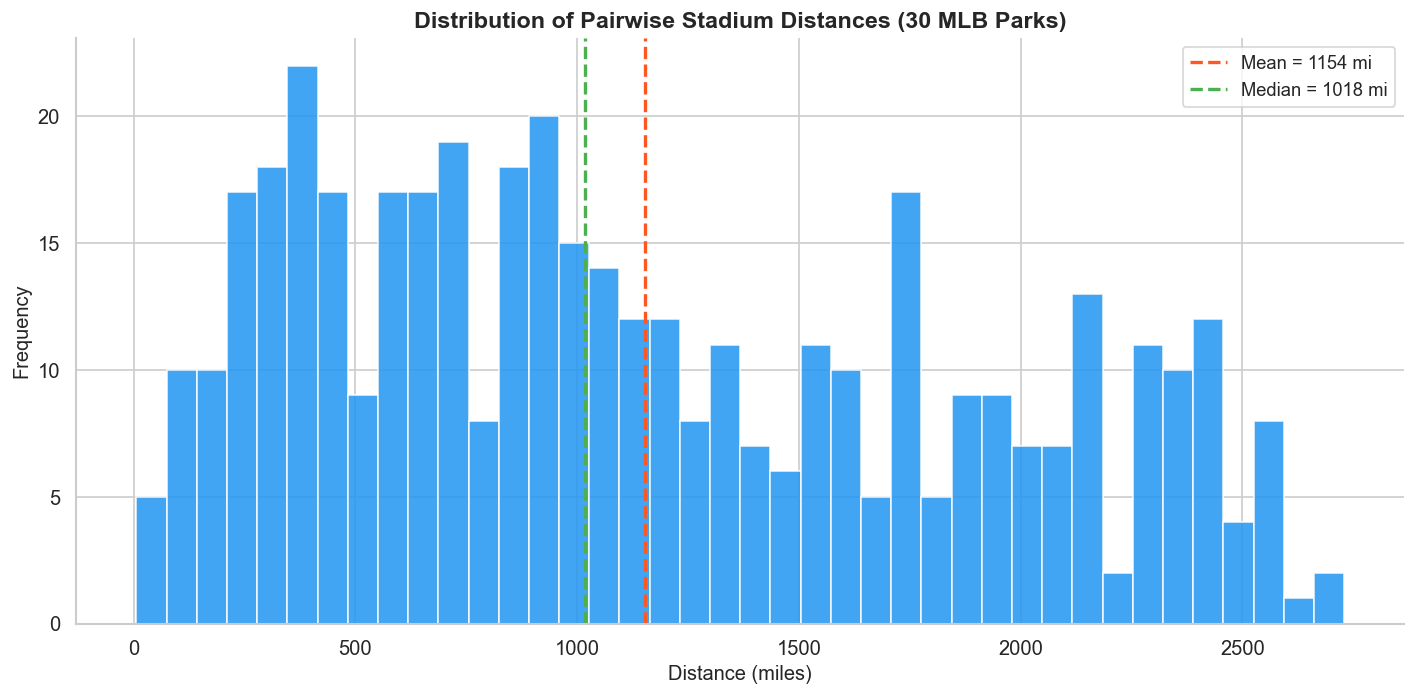


Pairwise distance stats:
  Count : 435 pairs
  Mean  : 1,154 miles
  Median: 1,018 miles
  Min   : 6 miles
  Max   : 2,729 miles
  Std   : 720 miles


In [12]:
# ---- Histogram of pairwise distances ----
upper_tri = dist_matrix.values[np.triu_indices(len(home_parks), k=1)]

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(upper_tri, bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(upper_tri), color='#FF5722', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(upper_tri):.0f} mi')
ax.axvline(np.median(upper_tri), color='#4CAF50', linestyle='--', linewidth=2,
           label=f'Median = {np.median(upper_tri):.0f} mi')

ax.set_title('Distribution of Pairwise Stadium Distances (30 MLB Parks)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Distance (miles)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

print(f'\nPairwise distance stats:')
print(f'  Count : {len(upper_tri)} pairs')
print(f'  Mean  : {np.mean(upper_tri):,.0f} miles')
print(f'  Median: {np.median(upper_tri):,.0f} miles')
print(f'  Min   : {np.min(upper_tri):,.0f} miles')
print(f'  Max   : {np.max(upper_tri):,.0f} miles')
print(f'  Std   : {np.std(upper_tri):,.0f} miles')

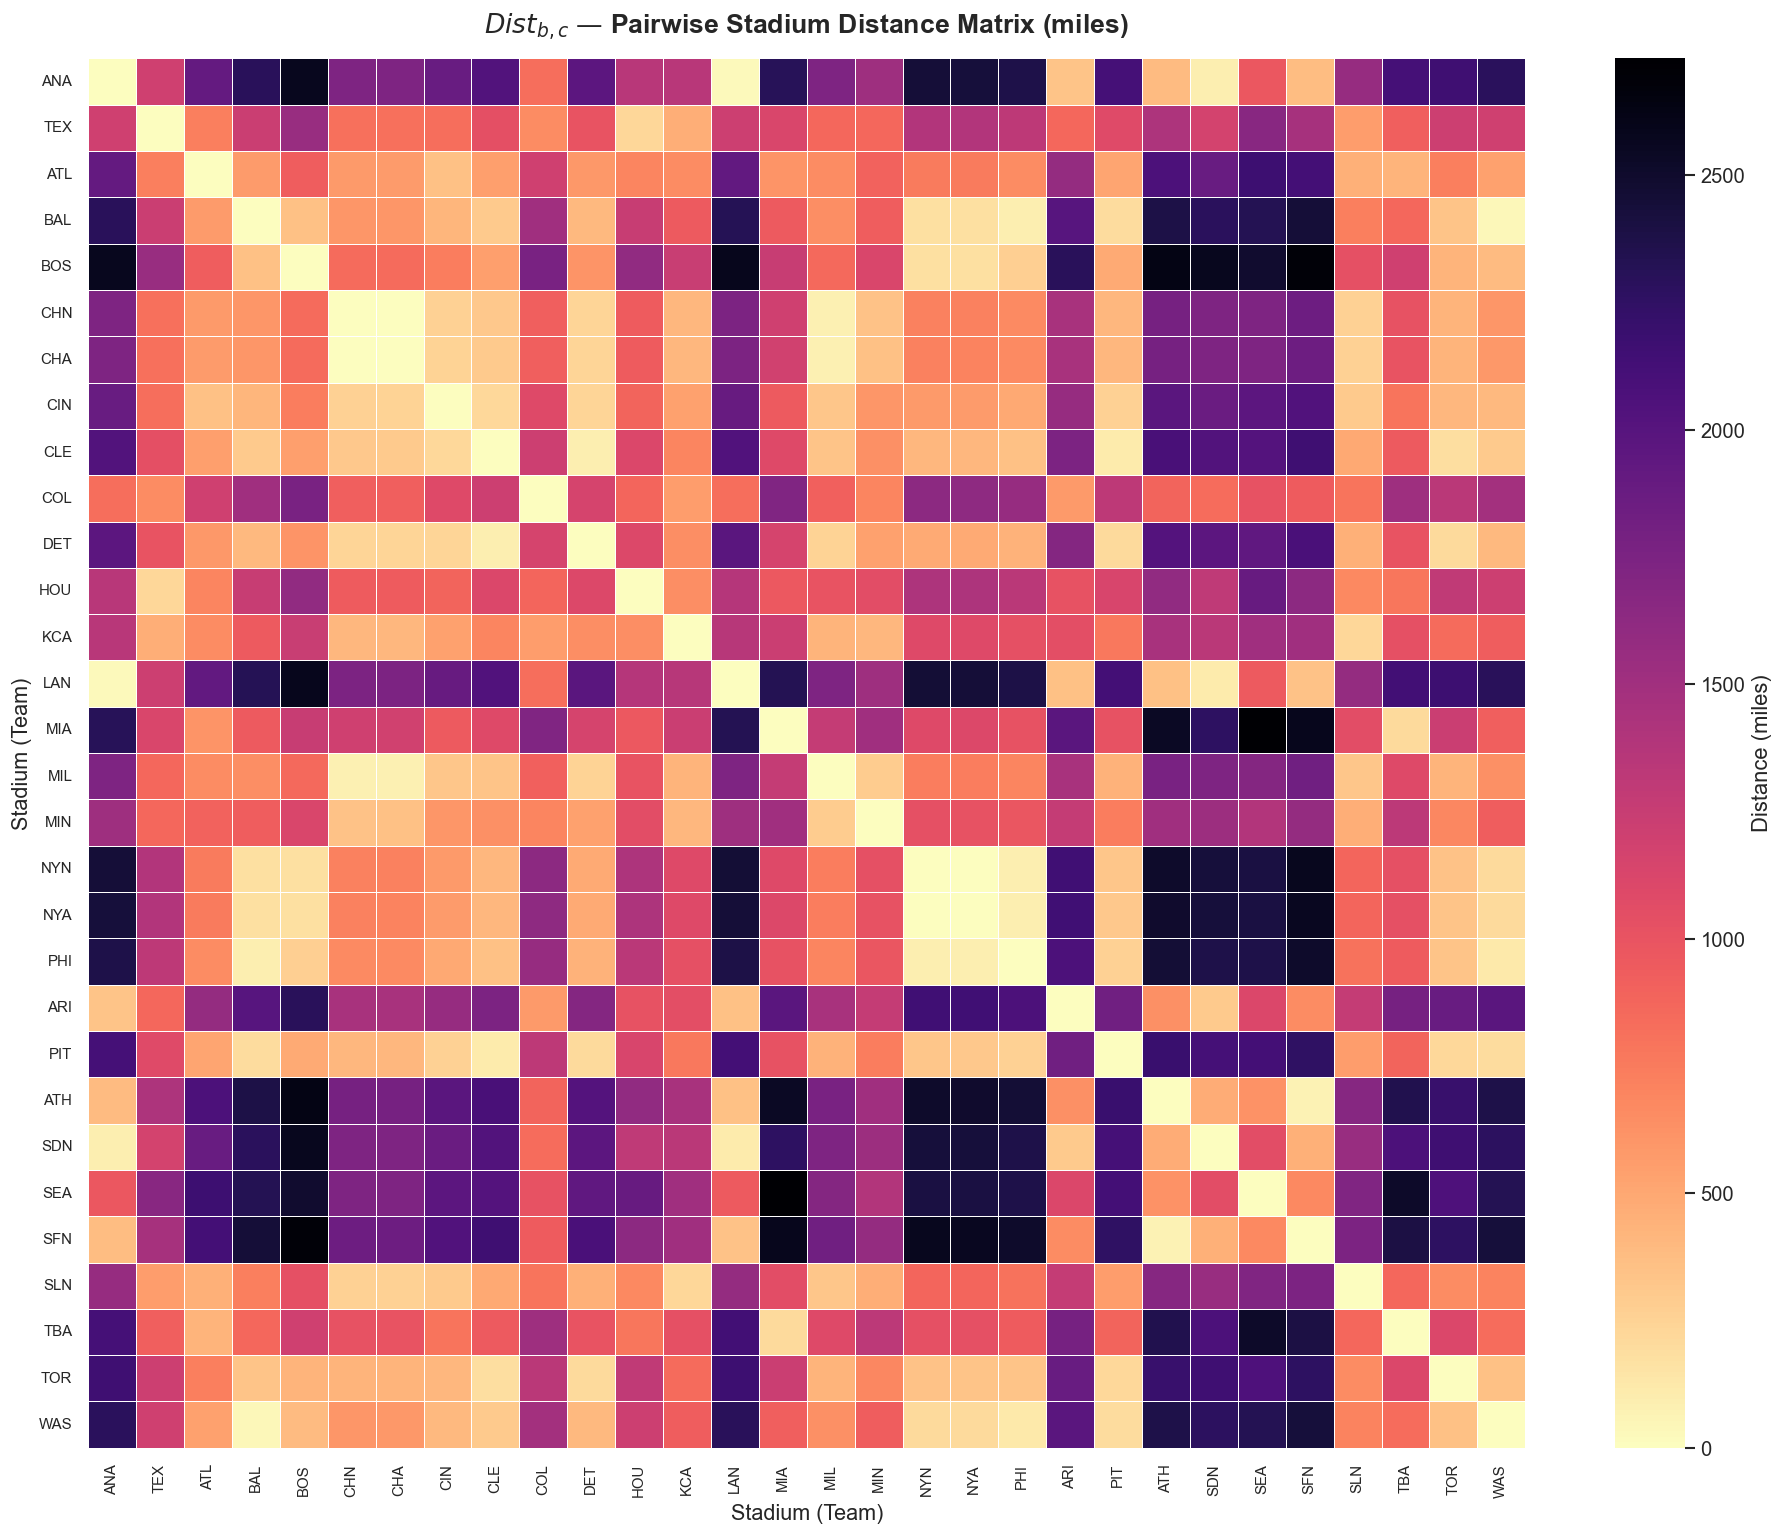


--- MILP Justification ---
This symmetric matrix Dist(b,c) is the coefficient on the binary
routing variable A(a,b,c,d) in the objective function.
It captures the cost of each team traveling from stadium b to stadium c.


In [13]:
# ---- Distance matrix heatmap (team-labeled) ----
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    dist_by_team,
    annot=False,
    cmap='magma_r',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Distance (miles)'},
    ax=ax
)
ax.set_title('$Dist_{b,c}$ — Pairwise Stadium Distance Matrix (miles)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Stadium (Team)', fontsize=13)
ax.set_ylabel('Stadium (Team)', fontsize=13)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.show()

print('\n--- MILP Justification ---')
print('This symmetric matrix Dist(b,c) is the coefficient on the binary')
print('routing variable A(a,b,c,d) in the objective function.')
print('It captures the cost of each team traveling from stadium b to stadium c.')

---
## Task 4 — Baseline Objective Value (Historical Benchmarking)

We reconstruct each team's *actual* travel itinerary from the 2025 Retrosheet
game log and compute:
1. **Single-team example** (e.g., SEA) — total miles traveled.
2. **League-wide total** — sum over all 30 teams.

This league-wide value serves as the **upper bound / baseline** for our MILP
objective.  A valid optimization should produce a total ≤ this baseline.

In [14]:
# ============================================================
# TASK 4:  BASELINE TRAVEL DISTANCE
# ============================================================

def get_team_travel(team_id, game_log, team_home_map, stadium_coordinates):
    """
    Calculate the total travel distance for a single team across the season.
    
    Travel logic:
    - When a team is the home team, they are at their home park.
    - When a team is the visiting team, they are at the game's ParkID.
    - Travel occurs between consecutive game locations.
    - At season start, the team starts at their home park.
    - At season end, the team returns to their home park.
    
    Returns: (total_miles, list of (date, location, leg_distance) tuples)
    """
    # Get all games involving this team (home or away), sorted by date
    team_games = game_log[
        (game_log['HomeTeam'] == team_id) | (game_log['VisitingTeam'] == team_id)
    ].sort_values('Date').reset_index(drop=True)
    
    home_park = team_home_map[team_id]
    total_miles = 0.0
    legs = []
    prev_location = home_park  # Start at home
    
    for _, game in team_games.iterrows():
        # Determine where this game takes place
        game_location = game['ParkID']
        
        # Skip neutral-site international games (Tokyo) for domestic travel calc
        if game_location not in stadium_coordinates:
            continue
        
        # Calculate travel from previous location to this game's location
        if prev_location != game_location and prev_location in stadium_coordinates:
            d = haversine_miles(
                stadium_coordinates[prev_location][2], stadium_coordinates[prev_location][3],
                stadium_coordinates[game_location][2], stadium_coordinates[game_location][3]
            )
            total_miles += d
            legs.append((game['Date'], f'{prev_location} → {game_location}', round(d, 1)))
        
        prev_location = game_location
    
    # Return home after the season
    if prev_location != home_park and prev_location in stadium_coordinates:
        d = haversine_miles(
            stadium_coordinates[prev_location][2], stadium_coordinates[prev_location][3],
            stadium_coordinates[home_park][2], stadium_coordinates[home_park][3]
        )
        total_miles += d
        legs.append(('End', f'{prev_location} → {home_park} (return home)', round(d, 1)))
    
    return total_miles, legs

print('Travel calculation function defined ✓')

Travel calculation function defined ✓


In [16]:
# --- Single-Team Example: Chicago Cubs (CUBS) ---
example_team = 'CHN'
cubs_miles, cubs_legs = get_team_travel(example_team, gl, H_a, stadium_coords)

print(f'=== {example_team} Chicago Cubs — 2025 Season Travel ===')
print(f'Total distance: {cubs_miles:,.0f} miles')
print(f'Number of travel legs: {len(cubs_legs)}')
print(f'\nFirst 15 travel legs:')
for date, route, dist in cubs_legs[:15]:
    print(f'  {str(date)[:10]}  {route:35s}  {dist:>8,.1f} mi')
print('  ...')

=== CHN Chicago Cubs — 2025 Season Travel ===
Total distance: 36,530 miles
Number of travel legs: 40

First 15 travel legs:
  2025-03-18  CHI11 → TOK01                         6,292.1 mi
  2025-03-27  TOK01 → PHO01                         5,781.2 mi
  2025-03-31  PHO01 → SAC01                           635.3 mi
  2025-04-04  SAC01 → CHI11                         1,788.2 mi
  2025-04-11  CHI11 → LOS03                         1,740.8 mi
  2025-04-14  LOS03 → SAN02                           113.2 mi
  2025-04-18  SAN02 → CHI11                         1,731.4 mi
  2025-04-29  CHI11 → PIT08                           410.8 mi
  2025-05-02  PIT08 → MIL06                           447.5 mi
  2025-05-05  MIL06 → CHI11                            76.3 mi
  2025-05-09  CHI11 → NYC20                           720.2 mi
  2025-05-12  NYC20 → CHI11                           720.2 mi
  2025-05-19  CHI11 → MIA02                         1,194.7 mi
  2025-05-23  MIA02 → CIN09                           953

In [17]:
# --- League-Wide Total: All 30 Teams ---
team_travel_totals = {}

for team in T:
    miles, _ = get_team_travel(team, gl, H_a, stadium_coords)
    team_travel_totals[team] = round(miles)

travel_df = pd.DataFrame(
    list(team_travel_totals.items()),
    columns=['Team', 'TotalMiles']
).sort_values('TotalMiles', ascending=False).reset_index(drop=True)

# Add city/nickname
travel_df = travel_df.merge(
    teams_df[['TeamID', 'City', 'Nickname']],
    left_on='Team', right_on='TeamID'
).drop(columns='TeamID')

league_total = travel_df['TotalMiles'].sum()

print(f'LEAGUE-WIDE TOTAL TRAVEL : {league_total:>12,} miles')
print(f'Average per team         : {league_total/30:>12,.0f} miles')
print(f'Max (most travel)        : {travel_df.iloc[0]["Team"]} — {travel_df.iloc[0]["TotalMiles"]:,} miles')
print(f'Min (least travel)       : {travel_df.iloc[-1]["Team"]} — {travel_df.iloc[-1]["TotalMiles"]:,} miles')
print()
travel_df[['Team', 'City', 'Nickname', 'TotalMiles']]

LEAGUE-WIDE TOTAL TRAVEL :    1,087,682 miles
Average per team         :       36,256 miles
Max (most travel)        : LAN — 55,093 miles
Min (least travel)       : CLE — 26,181 miles



,Team,City,Nickname,TotalMiles
0,LAN,Los Angeles,Dodgers,55093
1,ATH,Sacramento,Athletics,48947
2,SFN,San Francisco,Giants,46513
3,SDN,San Diego,Padres,45439
4,ANA,Anaheim,Angels,45047
5,SEA,Seattle,Mariners,44437
6,ARI,Arizona,Diamondbacks,42082
7,MIA,Miami,Marlins,39898
8,TEX,Texas,Rangers,38268
9,HOU,Houston,Astros,38110


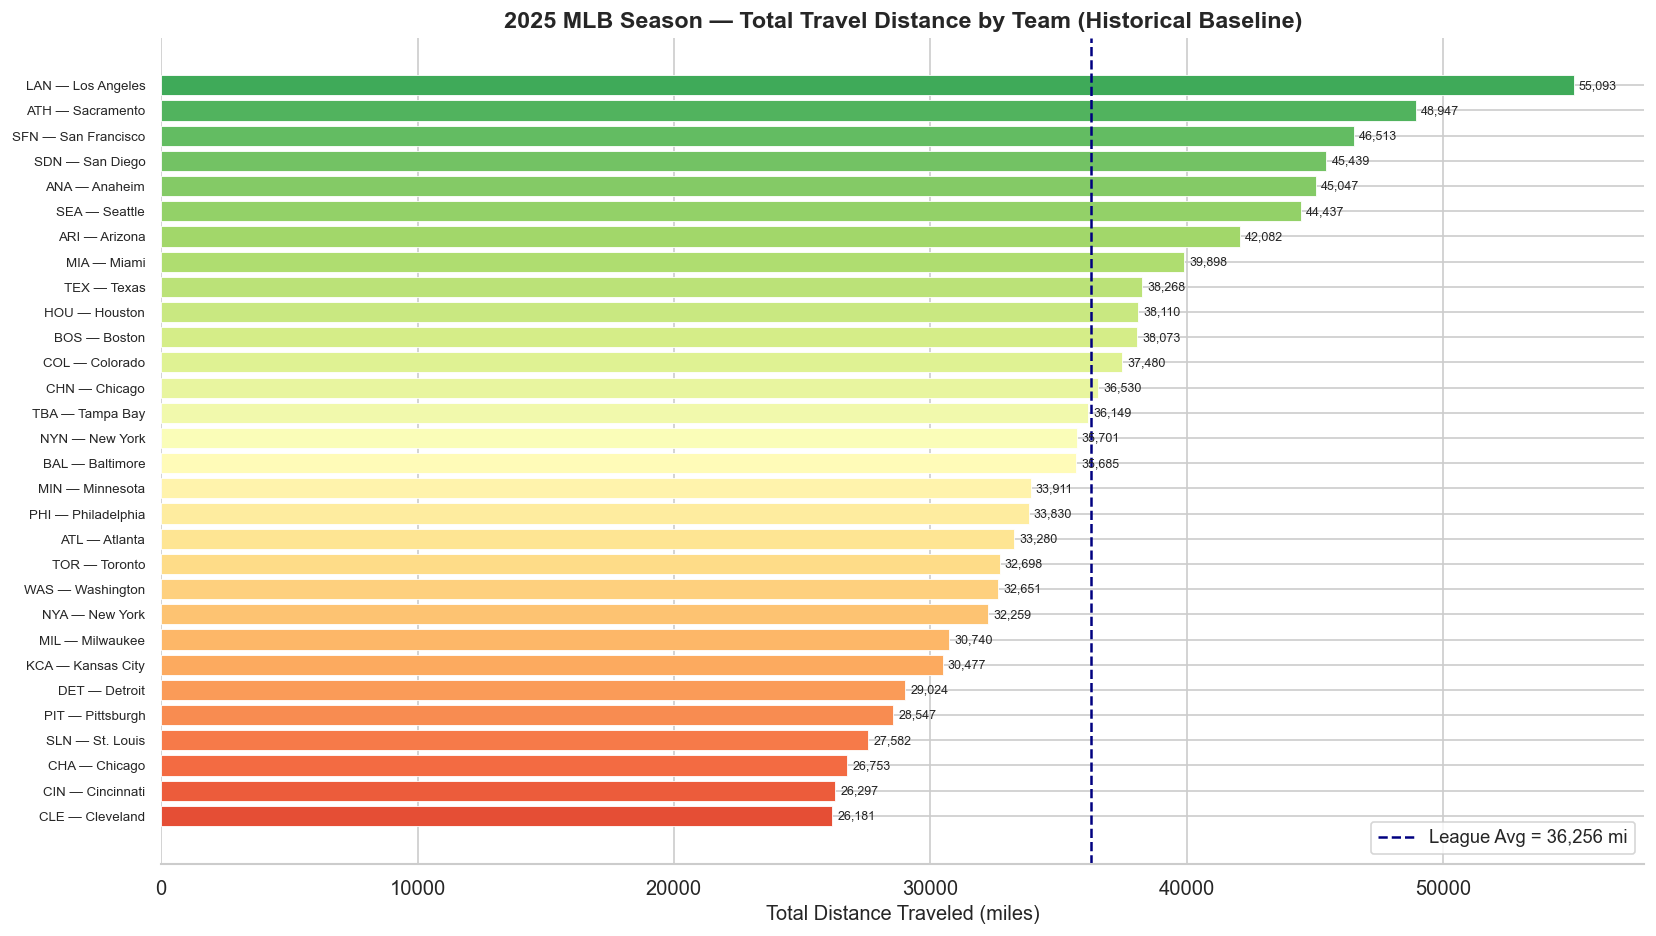

In [18]:
# ---- Bar Chart: Travel Distance by Team ----
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(travel_df)))

bars = ax.barh(
    travel_df['Team'] + ' — ' + travel_df['City'],
    travel_df['TotalMiles'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

ax.axvline(league_total / 30, color='navy', linestyle='--', linewidth=1.5,
           label=f'League Avg = {league_total/30:,.0f} mi')

ax.set_xlabel('Total Distance Traveled (miles)', fontsize=12)
ax.set_title('2025 MLB Season — Total Travel Distance by Team (Historical Baseline)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=8)

# Add value labels
for bar, val in zip(bars, travel_df['TotalMiles']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', ha='left', va='center', fontsize=7.5)

sns.despine(left=True)
plt.tight_layout()
plt.show()

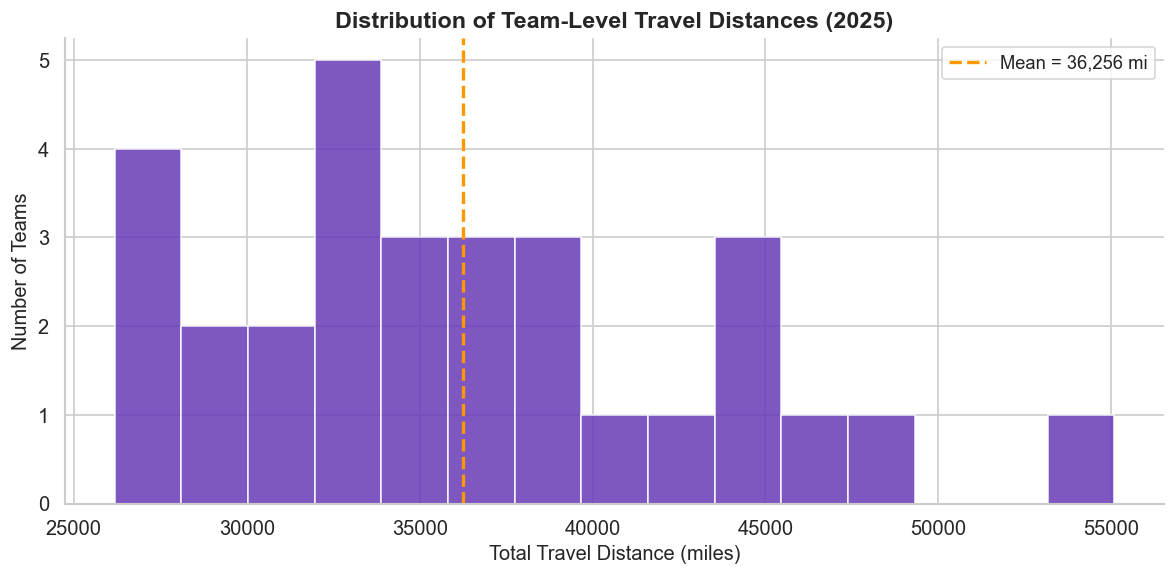

In [19]:
# ---- Distribution of per-team travel ----
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(travel_df['TotalMiles'], bins=15, color='#673AB7', edgecolor='white', alpha=0.85)
ax.axvline(league_total / 30, color='#FF9800', linestyle='--', linewidth=2,
           label=f'Mean = {league_total/30:,.0f} mi')
ax.set_title('Distribution of Team-Level Travel Distances (2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Travel Distance (miles)', fontsize=12)
ax.set_ylabel('Number of Teams', fontsize=12)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

---
## Summary & MILP Baseline

### Key Results

| Parameter | Value | MILP Role |
|---|---|---|
| $|T|$ | 30 teams | Index set for team variables |
| $|C|$ | 30 home stadiums | Index set for location variables |
| $H_a$ | Team → Park mapping | Constraint: fixes home location |
| $M_{a,j}$ | 30×30 matchup matrix | Constraint: $\sum_d G_{a,j,d} = M_{a,j}$ |
| $Dist_{b,c}$ | 30×30 distance matrix | Objective coefficient on travel arcs |
| **Baseline** | League-wide total miles | **Upper bound** for objective |

### MILP Objective Interpretation

The historical league-wide travel distance serves as our **benchmark**. If the
MILP solver produces a schedule with total travel *less than* this baseline while
satisfying all constraints, then the optimizer has found a more efficient schedule.

$$\text{Improvement} = \frac{\text{Baseline} - \text{Optimized}}{\text{Baseline}} \times 100\%$$

In [21]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print('=' * 60)
print('   MLB SCHEDULE OPTIMIZATION — EDA SUMMARY')
print('=' * 60)
print(f'  Season            : 2025 MLB')
print(f'  Teams |T|         : {len(T)}')
print(f'  Home Parks |C|    : {len(home_parks)}')
print(f'  Games in log      : {len(gl):,}')
print(f'  Total in M(a,j)   : {M_aj.values.sum():,}')
print(f'  Avg park distance : {np.mean(upper_tri):,.0f} miles')
print(f'  ─────────────────────────────────────────')
print(f'  BASELINE OBJECTIVE (league travel) : {league_total:>10,} miles')
print(f'  Per-team average                   : {league_total//30:>10,} miles')
print('=' * 60)
print('\nAll parameters are ready for Pyomo model construction.')

   MLB SCHEDULE OPTIMIZATION — EDA SUMMARY
  Season            : 2025 MLB
  Teams |T|         : 30
  Home Parks |C|    : 30
  Games in log      : 2,430
  Total in M(a,j)   : 2,430
  Avg park distance : 1,154 miles
  ─────────────────────────────────────────
  BASELINE OBJECTIVE (league travel) :  1,087,682 miles
  Per-team average                   :     36,256 miles

All parameters are ready for Pyomo model construction.
